# Bibliotekos

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

# Duomenys

In [2]:
min_max_data = pd.read_csv('full_min_max_data.csv')
min_max_data.head(5)

,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,annual.inc,credit.policy,purpose,not.fully.paid
0,0.088433,0.404762,0.252568,0.006169,0.901408,0.000000,0.0,0.0,0.015173,0,all_other,0
1,0.034633,0.285714,0.199361,0.009275,0.413146,0.148148,0.0,0.0,0.049939,0,all_other,1
2,0.504371,0.214286,0.000000,0.000000,0.448826,0.037037,0.0,0.0,0.000344,0,all_other,0
3,0.336247,0.333333,0.218260,0.000000,0.203756,0.148148,0.0,0.0,0.086767,0,all_other,0
4,0.187962,0.547619,0.408971,0.011692,0.646948,0.222222,0.0,0.0,0.050030,0,all_other,0


In [3]:
print(min_max_data.dtypes)

dti                  float64
fico                 float64
days.with.cr.line    float64
revol.bal            float64
revol.util           float64
inq.last.6mths       float64
delinq.2yrs          float64
pub.rec              float64
annual.inc           float64
credit.policy          int64
purpose                  str
not.fully.paid         int64
dtype: object


In [4]:
cols_to_factor = ['credit.policy', 'not.fully.paid', 'purpose']
for col in cols_to_factor:
    min_max_data[col] = min_max_data[col].astype('category')
print(min_max_data.dtypes)

dti                   float64
fico                  float64
days.with.cr.line     float64
revol.bal             float64
revol.util            float64
inq.last.6mths        float64
delinq.2yrs           float64
pub.rec               float64
annual.inc            float64
credit.policy        category
purpose              category
not.fully.paid       category
dtype: object


In [5]:
t_sne_data = pd.read_csv('tsne_data.csv')
t_sne_data.head(5)

,tsne_1,tsne_2
0,26.358140,-36.141340
1,-20.423824,-36.142470
2,8.535892,8.222071
3,-6.836975,3.511418
4,8.652580,-32.706192


# Klasterizavimas ant orginalių duomenų

### Klasterių skaičiaus nustatymas

#### Empyrinis metodas

In [6]:
print('Klasterių skaičius: ', round(np.sqrt(len(min_max_data)/2)))

Klasterių skaičius:  44


#### Alkūnės metodas ir Vidutinio silueto metodas

Klasterių skaičius:  2 Vidutinis silueto metodas:  0.29956359116413495
Klasterių skaičius:  3 Vidutinis silueto metodas:  0.23387312749232003
Klasterių skaičius:  4 Vidutinis silueto metodas:  0.21879937484326492
Klasterių skaičius:  5 Vidutinis silueto metodas:  0.19586426921258024
Klasterių skaičius:  6 Vidutinis silueto metodas:  0.1859393549607753
Klasterių skaičius:  7 Vidutinis silueto metodas:  0.18657291727349684
Klasterių skaičius:  8 Vidutinis silueto metodas:  0.17107492582297376
Klasterių skaičius:  9 Vidutinis silueto metodas:  0.1725554673598414
Klasterių skaičius:  10 Vidutinis silueto metodas:  0.16742744528253975


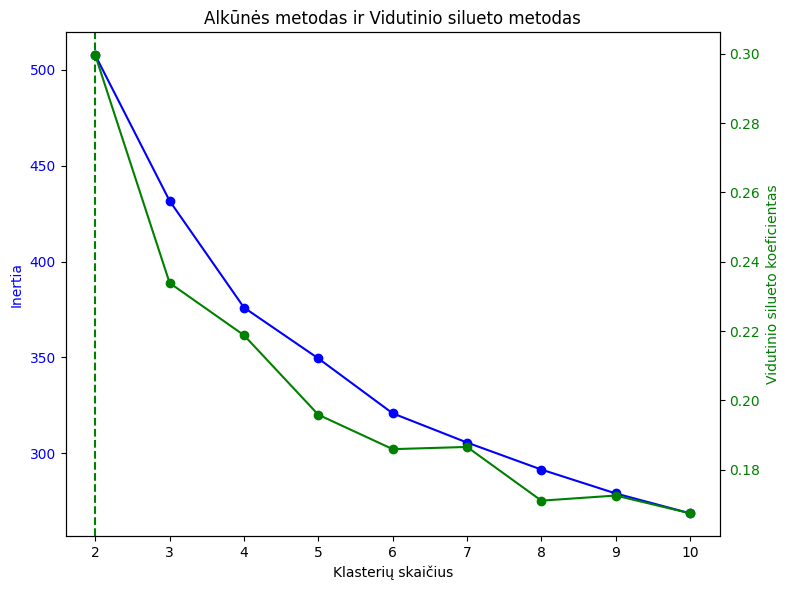

In [7]:
min_max_numeric = min_max_data.select_dtypes(include='number')
inertias = []
all_silhouette_avg = []

for i in range(2,11):
    kmeans = KMeans(n_clusters=i, random_state=2026)
    cluster_labels = kmeans.fit_predict(min_max_numeric)
    inertias.append(kmeans.inertia_)

    silhouette_avg = silhouette_score(min_max_numeric, cluster_labels)
    all_silhouette_avg.append(silhouette_avg)
    print("Klasterių skaičius: ", i,
        "Vidutinis silueto metodas: ", silhouette_avg)

fig, ax1 = plt.subplots(figsize=(8, 6))

best_index = np.argmax(all_silhouette_avg)
best_k = range(2, 11)[best_index]

ax1.plot(range(2,11), inertias, 'bo-')
ax1.set_xlabel('Klasterių skaičius')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(range(2,11), all_silhouette_avg, 'go-')
ax2.set_ylabel('Vidutinio silueto koeficientas', color='g')
ax2.tick_params(axis='y', labelcolor='g')
ax2.axvline(x=best_k, color="g", linestyle="--")

plt.title('Alkūnės metodas ir Vidutinio silueto metodas')
fig.tight_layout()
plt.show()


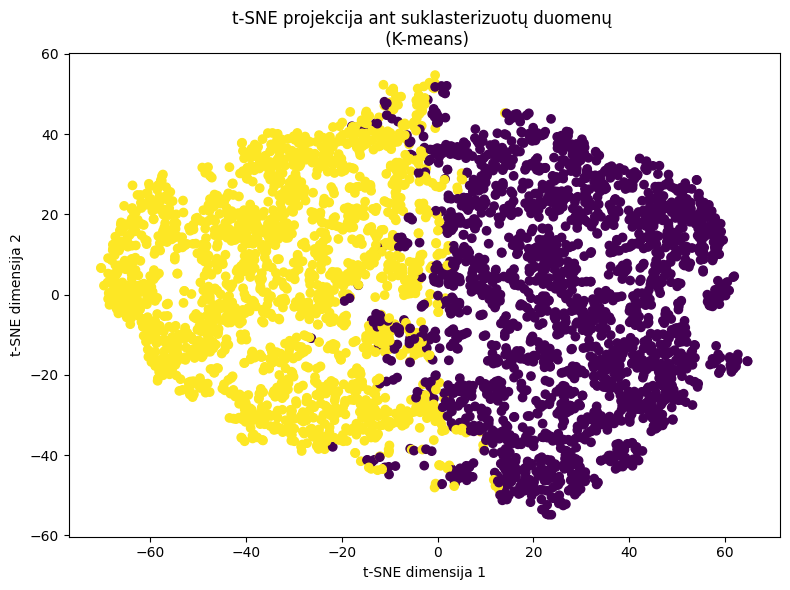

In [8]:
kmeans = KMeans(n_clusters=best_k, random_state=2026)
kmeans.fit(min_max_data.select_dtypes(include='number'))

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.scatter(t_sne_data['tsne_1'], t_sne_data['tsne_2'], c=kmeans.labels_, cmap='viridis')
ax1.set_xlabel('t-SNE dimensija 1')
ax1.set_ylabel('t-SNE dimensija 2')

plt.title('t-SNE projekcija ant suklasterizuotų duomenų \n (K-means)')
fig.tight_layout()
plt.show()

# Klasterizavimas ant sumažintos dimensijos

### Klasterių skaičiaus nustatymas

#### Empyrinis metodas

In [9]:
print('Klasterių skaičius: ', round(np.sqrt(len(t_sne_data)/2)))

Klasterių skaičius:  44


#### Alkūnės metodas ir Vidutinio silueto metodas

Klasterių skaičius:  2 Vidutinis silueto metodas:  0.423460225968274
Klasterių skaičius:  3 Vidutinis silueto metodas:  0.4031732252015935
Klasterių skaičius:  4 Vidutinis silueto metodas:  0.3743001920453979
Klasterių skaičius:  5 Vidutinis silueto metodas:  0.38930310041660304
Klasterių skaičius:  6 Vidutinis silueto metodas:  0.37200418009471325
Klasterių skaičius:  7 Vidutinis silueto metodas:  0.3801922375000445
Klasterių skaičius:  8 Vidutinis silueto metodas:  0.38300881194855196
Klasterių skaičius:  9 Vidutinis silueto metodas:  0.3725770900739087
Klasterių skaičius:  10 Vidutinis silueto metodas:  0.38413918027998595


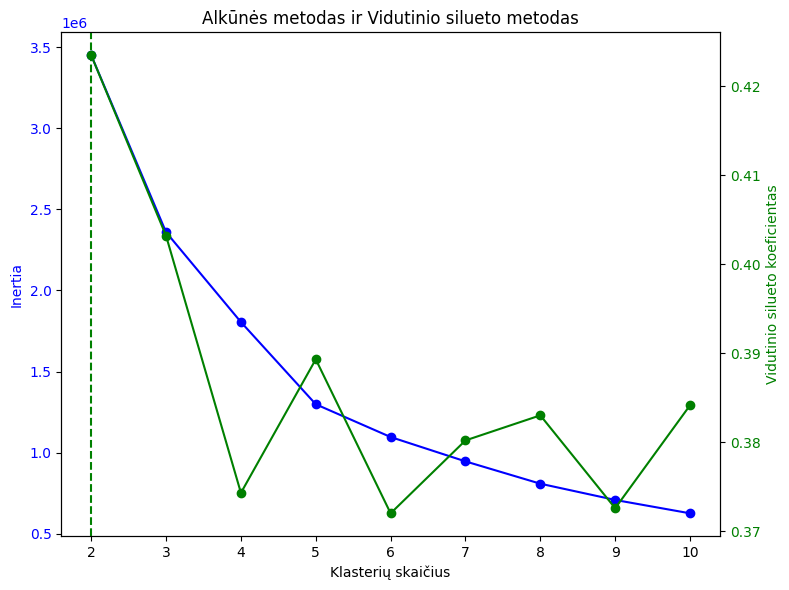

In [10]:

inertias = []
all_silhouette_avg = []

for i in range(2,11):
    kmeans = KMeans(n_clusters=i, random_state=2026)
    cluster_labels = kmeans.fit_predict(t_sne_data)
    inertias.append(kmeans.inertia_)

    silhouette_avg = silhouette_score(t_sne_data, cluster_labels)
    all_silhouette_avg.append(silhouette_avg)
    print("Klasterių skaičius: ", i,
        "Vidutinis silueto metodas: ", silhouette_avg)

fig, ax1 = plt.subplots(figsize=(8, 6))

best_index = np.argmax(all_silhouette_avg)
best_k = range(2, 11)[best_index]

ax1.plot(range(2,11), inertias, 'bo-')
ax1.set_xlabel('Klasterių skaičius')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(range(2,11), all_silhouette_avg, 'go-')
ax2.set_ylabel('Vidutinio silueto koeficientas', color='g')
ax2.tick_params(axis='y', labelcolor='g')
ax2.axvline(x=best_k, color="g", linestyle="--")

plt.title('Alkūnės metodas ir Vidutinio silueto metodas')
fig.tight_layout()
plt.show()


In [11]:
# inertias = []

# for i in range(1,11):
#     kmeans = KMeans(n_clusters=i,  random_state=2026)
#     kmeans.fit(t_sne_data.select_dtypes(include='number'))
#     inertias.append(kmeans.inertia_)

# plt.plot(range(1,11), inertias, marker='o')
# plt.title('Elbow method')
# plt.xlabel('Number of clusters')
# plt.ylabel('Inertia')
# plt.show()

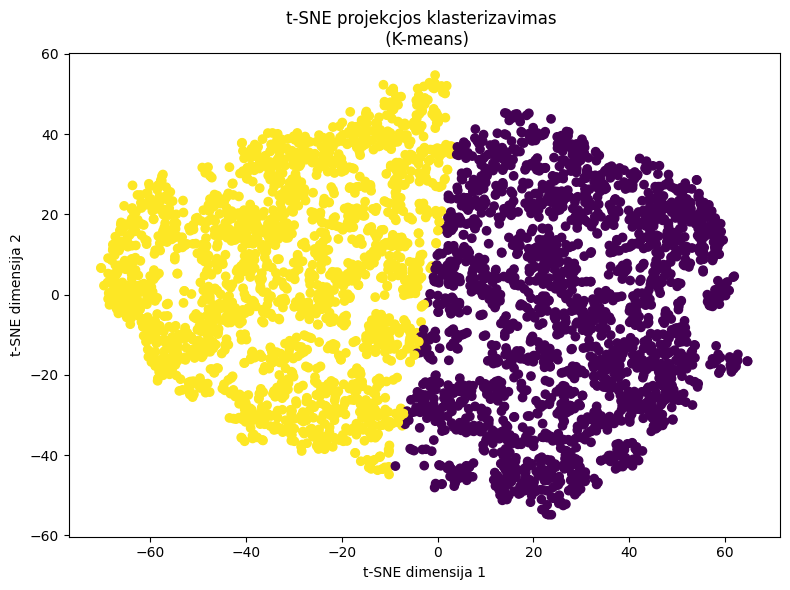

In [12]:
kmeans = KMeans(n_clusters=best_k,  random_state=2026)
kmeans.fit(t_sne_data)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.scatter(t_sne_data['tsne_1'], t_sne_data['tsne_2'], c=kmeans.labels_, cmap='viridis')
ax1.set_xlabel('t-SNE dimensija 1')
ax1.set_ylabel('t-SNE dimensija 2')

plt.title('t-SNE projekcjos klasterizavimas \n (K-means)')
fig.tight_layout()
plt.show()

# Požymių atrinkimas

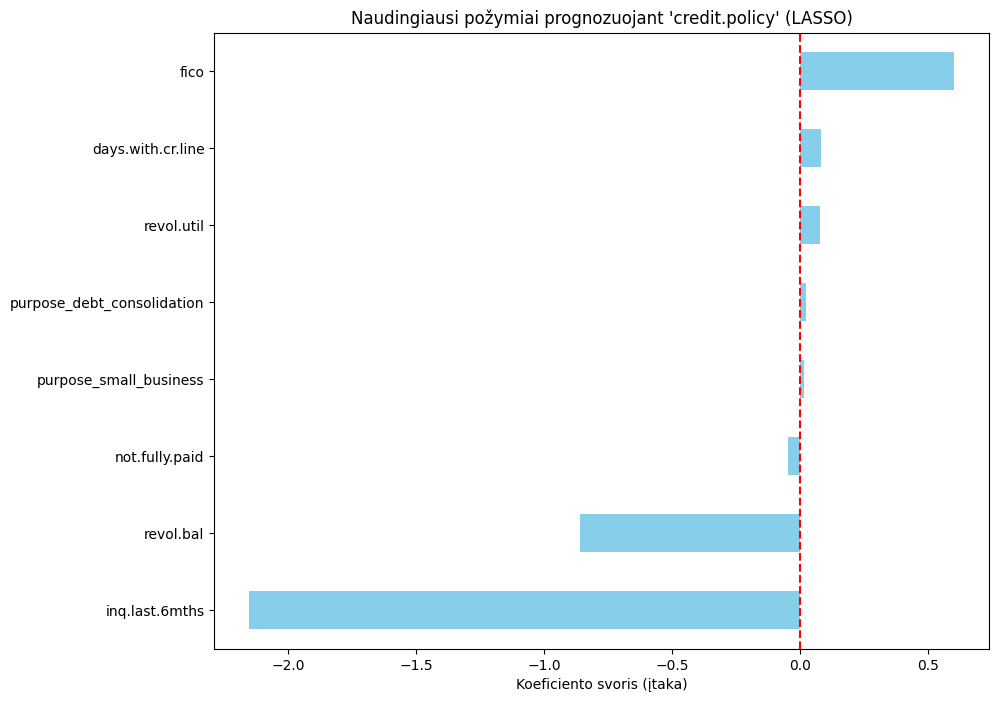

LASSO atmetė šiuos požymius kaip nenaudingus: ['dti', 'delinq.2yrs', 'pub.rec', 'annual.inc', 'purpose_credit_card', 'purpose_educational', 'purpose_home_improvement', 'purpose_major_purchase']


In [15]:
import pandas as pd
from sklearn.linear_model import LassoCV
import matplotlib.pyplot as plt
import numpy as np

data_with_dummies = pd.get_dummies(min_max_data, columns=['purpose'], drop_first=True)

X = data_with_dummies.drop(columns=['credit.policy'])
y = data_with_dummies['credit.policy']

lasso = LassoCV(cv=5, random_state=2026).fit(X, y)
coef = pd.Series(lasso.coef_, index=X.columns)

imp_coef = coef[coef != 0].sort_values()

plt.figure(figsize=(10, 8))
imp_coef.plot(kind = "barh", color='skyblue')
plt.title("Naudingiausi požymiai prognozuojant 'credit.policy' (LASSO)")
plt.xlabel("Koeficiento svoris (įtaka)")
plt.axvline(x=0, color='red', linestyle='--')
plt.show()

rejected = coef[coef == 0].index.tolist()
print(f"LASSO atmetė šiuos požymius kaip nenaudingus: {rejected}")